# Etapa 2  Análise Exploratória e Limpeza

**ImunizaData**  cobertura vacinal por município (SUS).

Este notebook lê o dataset já limpo e cruzado (`refined/cobertura_vacinal`,
gerado por `src/cleaning/build_coverage.py`) e faz a análise exploratória:
distribuição da métrica de cobertura, outliers, e o cruzamento com
população.

> Antes de rodar este notebook: `docker-compose up -d`, depois
> `python -m src.ingestion.download_ibge --ano 2024`,
> `python -m src.ingestion.download_pni --ano 2025`,
> `python -m src.cleaning.clean_ibge --ano 2024`,
> `python -m src.cleaning.clean_pni --ano 2025`,
> `python -m src.cleaning.build_coverage --ano 2025`
> (ajuste os anos conforme o escopo definido para o projeto).

In [1]:
import io
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import boto3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from botocore.client import Config
from scipy.stats import pearsonr, spearmanr

from src.config import MINIO_ACCESS_KEY, MINIO_ENDPOINT, MINIO_SECRET_KEY

sns.set_theme(style="whitegrid")

ANO = 2025
BUCKET_REFINED = os.getenv("MINIO_REFINED_BUCKET", "refined")

s3 = boto3.client(
    "s3",
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    config=Config(signature_version="s3v4"),
)

key = f"cobertura_vacinal/ano={ANO}/cobertura_municipios.parquet"
obj = s3.get_object(Bucket=BUCKET_REFINED, Key=key)
df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
df.shape

(5571, 10)

## 1. Visão geral

In [2]:
df.head()

,codigo_municipio,municipio,ano,populacao,unidade_medida,nivel_territorial,doses_aplicadas,cobertura_doses_por_100_habitantes,pib_mil_reais,pib_per_capita_reais
0,1100015,Alta Floresta D'Oeste - RO,9324,22787,Pessoas,Município,20283,89.01,1046343.0,45918.42
1,1100023,Ariquemes - RO,9324,109170,Pessoas,Município,86774,79.49,4383815.0,40155.86
2,1100031,Cabixi - RO,9324,5664,Pessoas,Município,3757,66.33,300832.0,53112.99
3,1100049,Cacoal - RO,9324,98280,Pessoas,Município,74367,75.67,3848468.0,39158.20
4,1100056,Cerejeiras - RO,9324,16966,Pessoas,Município,16918,99.72,1006389.0,59317.99


In [3]:
df.info()
print("\nValores ausentes por coluna:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   codigo_municipio                    5571 non-null   str    
 1   municipio                           5571 non-null   str    
 2   ano                                 5571 non-null   str    
 3   populacao                           5571 non-null   int64  
 4   unidade_medida                      5571 non-null   str    
 5   nivel_territorial                   5571 non-null   str    
 6   doses_aplicadas                     5571 non-null   int64  
 7   cobertura_doses_por_100_habitantes  5571 non-null   float64
 8   pib_mil_reais                       5570 non-null   float64
 9   pib_per_capita_reais                5570 non-null   float64
dtypes: float64(3), int64(2), str(5)
memory usage: 680.8 KB

Valores ausentes por coluna:
codigo_municipio                  

In [4]:
df["cobertura_doses_por_100_habitantes"].describe()

count    5571.000000
mean       84.257300
std        26.444305
min        16.590000
25%        73.240000
50%        82.310000
75%        92.765000
max      1606.410000
Name: cobertura_doses_por_100_habitantes, dtype: float64

## 2. Distribuição da cobertura vacinal

Lembrete: a métrica é "doses aplicadas por 100 habitantes" (proxy de
intensidade de vacinação), não "% de pessoas vacinadas" — ver
`docs/decisoes_limpeza.md`.

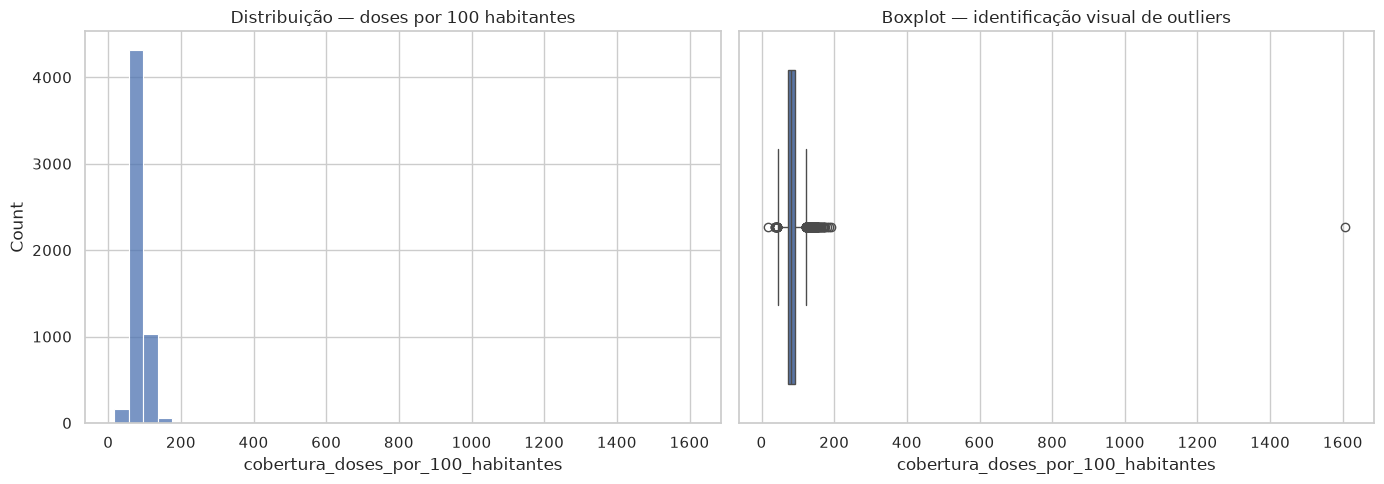

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["cobertura_doses_por_100_habitantes"], bins=40, ax=axes[0])
axes[0].set_title("Distribuição — doses por 100 habitantes")

sns.boxplot(x=df["cobertura_doses_por_100_habitantes"], ax=axes[1])
axes[1].set_title("Boxplot — identificação visual de outliers")

plt.tight_layout()
plt.savefig("../reports/distribuicao_cobertura.png", dpi=150)
plt.show()

## 3. Municípios extremos

Menor e maior cobertura — os de maior cobertura merecem checagem: podem ser
polos regionais de vacinação (atendem população de municípios vizinhos), o
que infla o numerador sem refletir a população local (ver coluna
`outlier_iqr` no dataset `trusted` de doses, por mês).

In [6]:
colunas_exibir = [
    "codigo_municipio",
    "municipio",
    "populacao",
    "doses_aplicadas",
    "cobertura_doses_por_100_habitantes",
]

print("10 municípios com MENOR cobertura:")
display(df.nsmallest(10, "cobertura_doses_por_100_habitantes")[colunas_exibir])

print("\n10 municípios com MAIOR cobertura:")
display(df.nlargest(10, "cobertura_doses_por_100_habitantes")[colunas_exibir])

10 municípios com MENOR cobertura:


,codigo_municipio,municipio,populacao,doses_aplicadas,cobertura_doses_por_100_habitantes
5199,5101837,Boa Esperança do Norte - MT,5877,975,16.59
3576,3527405,Lucélia - SP,20378,7287,35.76
3566,3526506,Lavínia - SP,9940,3588,36.10
4817,4310553,Itacurubi - RS,3038,1159,38.15
3849,3552304,Sud Mennucci - SP,7464,3022,40.49
2424,3116407,Claraval - MG,4786,1968,41.12
4973,4317004,Santana da Boa Vista - RS,7128,2945,41.32
3253,3305307,São Sebastião do Alto - RJ,7993,3375,42.22
1123,2404408,Grossos - RN,10281,4398,42.78
4989,4318101,São Francisco de Assis - RS,17934,7696,42.91



10 municípios com MAIOR cobertura:


,codigo_municipio,municipio,populacao,doses_aplicadas,cobertura_doses_por_100_habitantes
146,1400456,Pacaraima - RR,23112,371274,1606.41
79,1300201,Atalaia do Norte - AM,15889,30200,190.07
5203,5102603,Campinápolis - MT,15808,29507,186.66
5255,5106174,Nova Nazaré - MT,4575,8207,179.39
5141,5004403,Inocência - MS,8764,15318,174.78
123,1303601,Santa Isabel do Rio Negro - AM,13947,23831,170.87
53,1200054,Assis Brasil - AC,8648,14756,170.63
75,1300060,Amaturá - AM,11533,19478,168.89
81,1300409,Barcelos - AM,18210,30652,168.33
4872,4312625,Muliterno - RS,1754,2892,164.88


## 4. Cobertura vs. população

Municípios pequenos tendem a ter métricas mais voláteis (poucas doses já
mudam muito o percentual) — útil para decidir se vale a pena um corte
mínimo de população antes da Etapa 3 (clusterização/classificação).

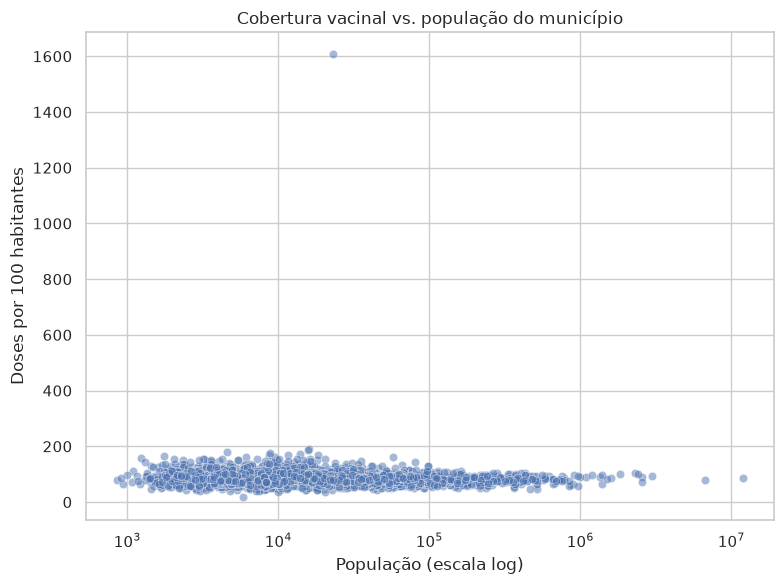

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="populacao",
    y="cobertura_doses_por_100_habitantes",
    alpha=0.5,
    ax=ax,
)
ax.set_xscale("log")
ax.set_xlabel("População (escala log)")
ax.set_ylabel("Doses por 100 habitantes")
ax.set_title("Cobertura vacinal vs. população do município")
plt.tight_layout()
plt.savefig("../reports/cobertura_vs_populacao.png", dpi=150)
plt.show()

## 5. Cobertura vs. PIB per capita (variável socioeconômica)

Renda per capita (PNAD Contínua) só existe a nível de Brasil/UF, e o IDH
municipal está defasado (2010, sem atualização com o Censo 2022): nenhum
dos dois serve para cruzar com a cobertura por município. Coletamos PIB
per capita municipal (Tabela 5938 do IBGE/SIDRA, ano de referência 2023)
como variável socioeconômica no lugar; ver `docs/decisoes_limpeza.md`
(seção 3) para a justificativa completa dessa troca.

Um município (de 5.571) não tem PIB no trusted e fica de fora desta
análise (ver `pib_per_capita_reais` em `docs/dicionario_dados.md`).

Reportamos Pearson e Spearman lado a lado: Pearson só captura relação
linear, e a distribuição do PIB per capita é bem assimétrica (por isso a
escala log no gráfico), então Spearman (baseado em ranking, não em
valor bruto) é a checagem de robustez mais adequada aqui. Também
verificamos os municípios com maior PIB per capita: essa variável, no
Brasil, é conhecida por ser distorcida por municípios pequenos com forte
atividade industrial/extrativa concentrada (refinaria, mineradora,
hidrelétrica), onde um PIB per capita alto não significa necessariamente
que os moradores têm renda alta ou melhor acesso a serviços públicos.

Pearson:  r = 0.0539   (p-valor = 5.754e-05)
Spearman: rho = 0.1035   (p-valor = 9.546e-15)
Municípios incluídos: 5570 de 5571


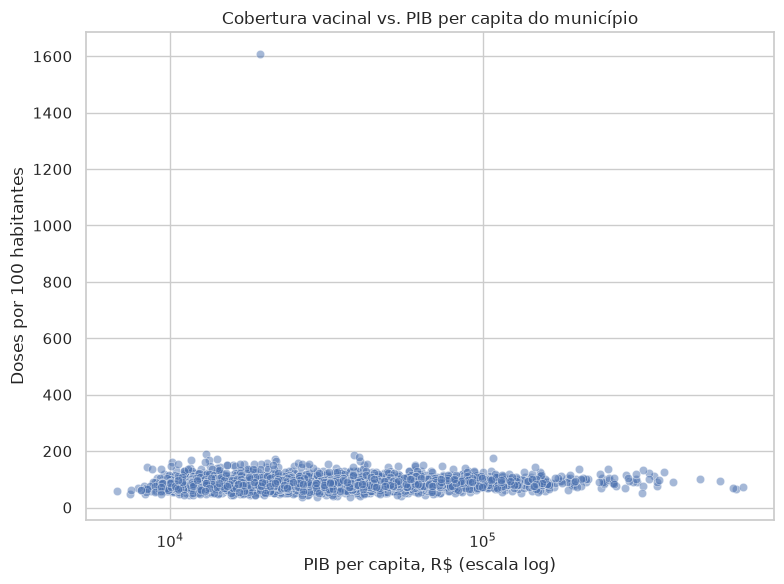

In [8]:
pib_valido = df.dropna(subset=["pib_per_capita_reais"])

pearson_r, pearson_p = pearsonr(
    pib_valido["cobertura_doses_por_100_habitantes"], pib_valido["pib_per_capita_reais"]
)
spearman_rho, spearman_p = spearmanr(
    pib_valido["cobertura_doses_por_100_habitantes"], pib_valido["pib_per_capita_reais"]
)

print(f"Pearson:  r = {pearson_r:.4f}   (p-valor = {pearson_p:.4g})")
print(f"Spearman: rho = {spearman_rho:.4f}   (p-valor = {spearman_p:.4g})")
print(f"Municípios incluídos: {len(pib_valido)} de {len(df)}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=pib_valido,
    x="pib_per_capita_reais",
    y="cobertura_doses_por_100_habitantes",
    alpha=0.5,
    ax=ax,
)
ax.set_xscale("log")
ax.set_xlabel("PIB per capita, R$ (escala log)")
ax.set_ylabel("Doses por 100 habitantes")
ax.set_title("Cobertura vacinal vs. PIB per capita do município")
plt.tight_layout()
plt.savefig("../reports/cobertura_vs_pib_per_capita.png", dpi=150)
plt.show()

In [9]:
colunas_pib = [
    "codigo_municipio",
    "municipio",
    "populacao",
    "pib_per_capita_reais",
    "pib_mil_reais",
]

print("5 municípios com MAIOR PIB per capita:")
display(df.nlargest(5, "pib_per_capita_reais")[colunas_pib])

5 municípios com MAIOR PIB per capita:


,codigo_municipio,municipio,populacao,pib_per_capita_reais,pib_mil_reais
3255,3305505,Saquarema - RJ,95315,678813.83,64701140.0
2183,2929206,São Francisco do Conde - BA,41110,644751.57,26505737.0
3215,3302700,Maricá - RJ,212470,631110.43,134092034.0
3677,3536505,Paulínia - SP,116674,574826.44,67067300.0
3155,3204302,Presidente Kennedy - ES,14852,496109.01,7368211.0


## 6. Conclusão e limitações

A correlação entre cobertura vacinal e PIB per capita municipal (seção 5)
é fraca, mas estatisticamente significativa nos dois critérios: Pearson
r = 0,0539 (p = 5,75e-05) e Spearman rho = 0,1035 (p = 9,55e-15). Com
5.570 municípios, até uma relação fraca fica "significativa"
estatisticamente: significância não é o mesmo que relevância prática
aqui. O fato de Spearman (baseado em ranking) dar quase o dobro de
Pearson sugere que existe, sim, uma leve associação positiva entre PIB
per capita e cobertura, só que distorcida pela distribuição enviesada do
PIB, não uma ilusão estatística.

Essa distorção fica evidente nos 5 municípios de maior PIB per capita
(seção 5): Saquarema-RJ, São Francisco do Conde-BA, Maricá-RJ,
Paulínia-SP e Presidente Kennedy-ES. Todos são casos conhecidos de
royalties de petróleo ou refinarias concentradas (São Francisco do Conde
tem a Refinaria Landulpho Alves; Maricá e Presidente Kennedy recebem
royalties do pré-sal; Paulínia tem a REPLAN), não municípios com
população genuinamente rica. Isso confirma a ressalva metodológica: PIB
per capita agregado é um proxy fraco para o bem-estar médio do morador
quando a atividade econômica está concentrada em poucas mãos/empresas,
então a correlação fraca encontrada aqui provavelmente reflete tanto uma
relação real fraca quanto ruído introduzido por esse tipo de distorção.

Os municípios com maior cobertura (seção 3) são majoritariamente polos de
fronteira (RR, AM, AC, MT), reforçando que fatores geográficos/logísticos
(atendimento a população de municípios vizinhos ou de outros países)
pesam mais nesse dataset do que a variável econômica testada aqui.

Limitações já documentadas em `docs/decisoes_limpeza.md` que continuam
valendo para a Etapa 3:

- A métrica é "doses aplicadas por 100 habitantes", não "% de pessoas
  vacinadas" (esquemas multidose inflam o numerador).
- O PIB é de 2023 (mais recente disponível na série do IBGE) cruzado com
  cobertura de 2025: defasagem de cerca de 2 anos entre as duas fontes.
- Um município ficou sem PIB no trusted e foi excluído da análise da
  seção 5.
- Para a Etapa 3, vale considerar uma variável de renda domiciliar per
  capita (menos sujeita à concentração industrial), se uma fonte
  municipal confiável for encontrada, no lugar do PIB agregado.